# Project 2
## Tahir Seha Üzümcü
## 

In [72]:
import numpy as np # Matrices and Advanced Mathematical Functions Library

import matplotlib.pyplot as plt # Plotting library for numpy

from scipy.interpolate import PchipInterpolator # Piecewise Cubic Hermite Interpolating Polynomial

from scipy.interpolate import CubicSpline # A module for Cubic Spline Interpolation


### Problem 1.a

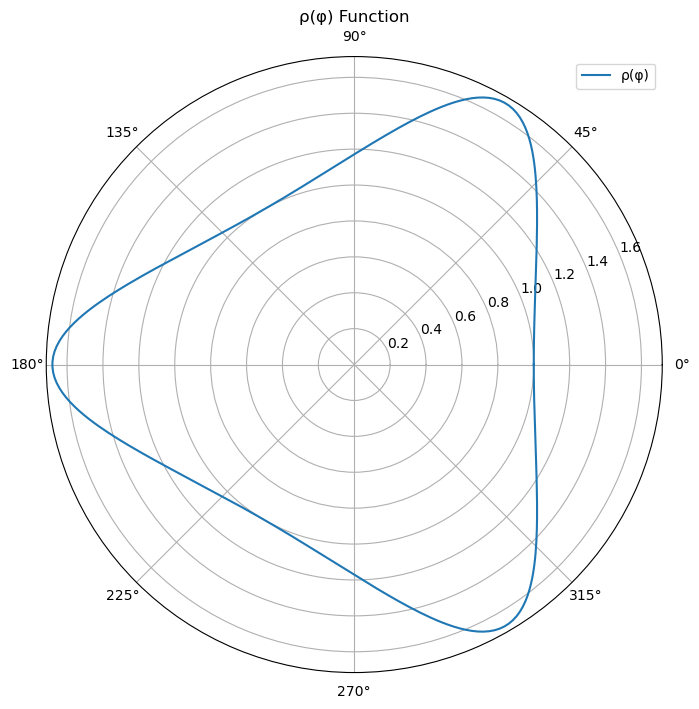

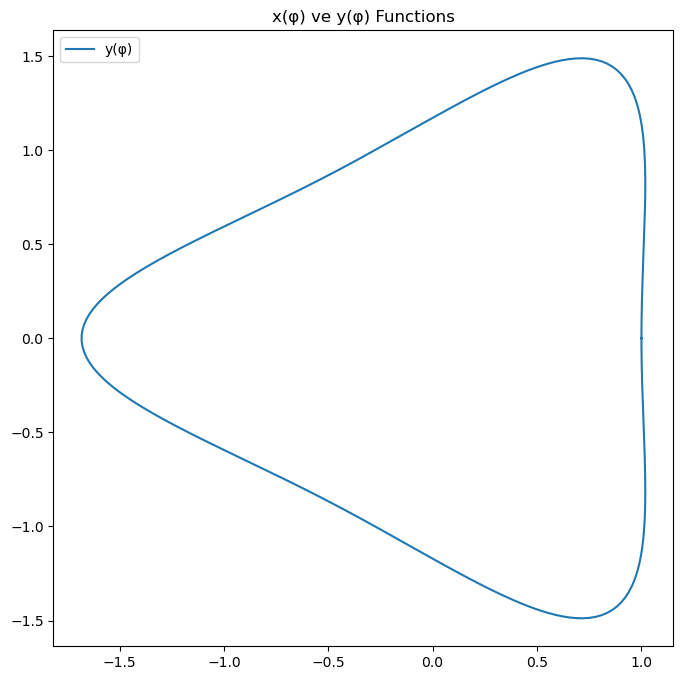

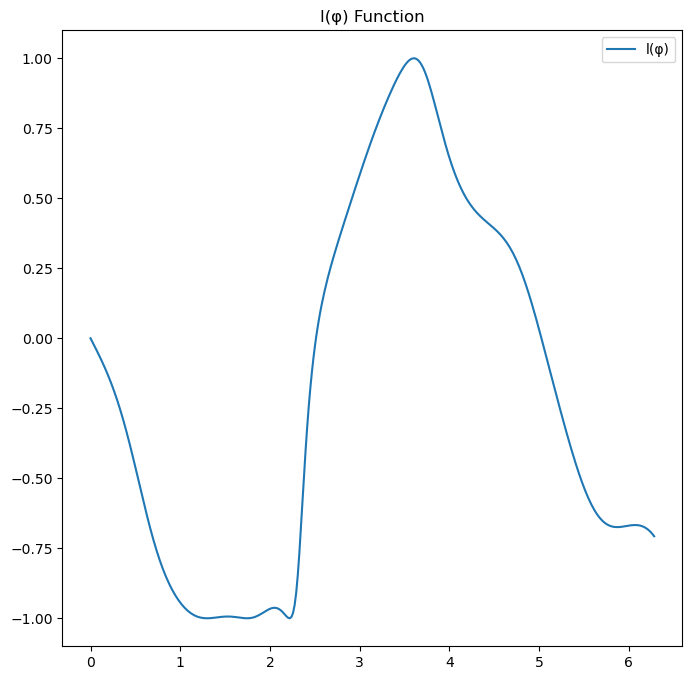

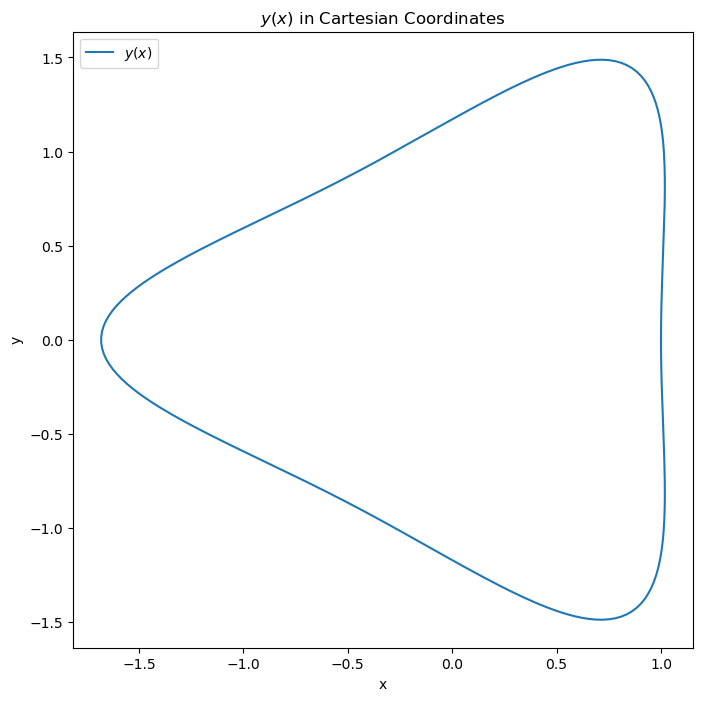

In [73]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3 * phi / 4))**8 + np.abs(np.sin(3 * phi / 4))**8)**(-1/4))

# 𝑥(𝜙) and 𝑦(𝜙) functions
def x(phi):
    return rho(phi) * np.cos(phi)

def y(phi):
    return rho(phi) * np.sin(phi)

# 𝒍(𝝓) function
def L(phi):
    dx_dphi = -rho(phi) * np.sin(phi) - (rho(phi)**9) * np.sin(9 * phi / 4)
    dy_dphi = rho(phi) * np.cos(phi) + (rho(phi)**9) * np.cos(9 * phi / 4)
    return np.sqrt(dx_dphi**2 + dy_dphi**2)

# Create 𝜙 at 360 points in the range [0, 2𝜋]
phi_values = np.linspace(0, 2 * np.pi, 360)

# Plot the function 𝜌(𝜙) in polar coordinates
plt.figure(figsize=(8, 8))
plt.polar(phi_values, rho(phi_values), label='ρ(φ)')
plt.title('ρ(φ) Function')
plt.legend()
plt.show()

# Plot the functions 𝑥(𝜙) and 𝑦(𝜙)
plt.figure(figsize=(8, 8))
plt.plot(x(phi_values), y(phi_values), label='y(φ)')
plt.title('x(φ) ve y(φ) Functions')
plt.legend()
plt.show()

# Plot the function 𝒍(𝝓)
plt.figure(figsize=(8, 8))
plt.plot(phi_values, 1/L(phi_values) * (np.cos(phi_values) * (-rho(phi_values) * np.sin(phi_values) - (rho(phi_values)**9) * np.sin(9 * phi_values / 4)) + np.sin(phi_values) * (rho(phi_values) * np.cos(phi_values) + (rho(phi_values)**9) * np.cos(9 * phi_values / 4))), label='l(φ)')
plt.title('l(φ) Function')
plt.legend()
plt.show()

# Plot the function 𝑦 with respect to x in Cartesian coordinates
plt.figure(figsize=(8, 8))
plt.plot(x(phi_values), y(phi_values), label=r'$y(x)$')
plt.title(r'$y(x)$ in Cartesian Coordinates')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

The function 𝜌(𝜙) has a complex structure consisting of the combination of cos and sin terms, and its graph changes cyclically in the range [0, 2𝜋] of 𝜙. In this graph, information can be obtained about how 𝜌(𝜙) values change depending on 𝜙 and the general form of the curve.

### Problem 1.b

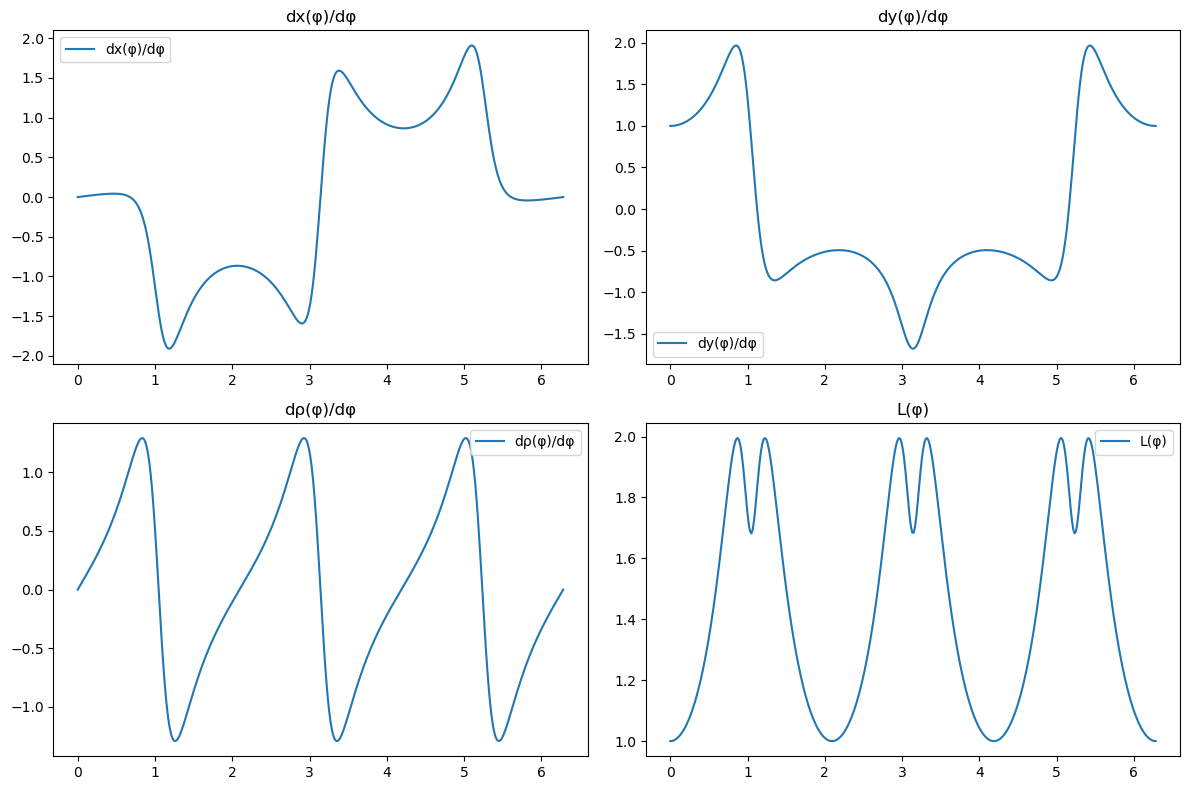

In [74]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3 * phi / 4))**8 + np.abs(np.sin(3 * phi / 4))**8)**(-1/4))

# 𝑥(𝜙) and 𝑦(𝜙) functions
def x(phi):
    return rho(phi) * np.cos(phi)

def y(phi):
    return rho(phi) * np.sin(phi)

# 𝑔(𝜙) = (𝑑𝜌(𝜙)/𝑑𝜙) function
def g(phi):
    return -3 * ((np.abs(np.cos(3 * phi / 4))**8 + np.abs(np.sin(3 * phi / 4))**8)**(5/4)) * np.sign(np.cos(3 * phi / 4)) * np.sin(3 * phi / 4)

# Forward differences formula
def forward_difference(func, phi, h=1e-5):
    return (func(phi + h) - func(phi)) / h

# Backward differences formula
def backward_difference(func, phi, h=1e-5):
    return (func(phi) - func(phi - h)) / h

# 3-point endpoint formula
def three_point_end(func, phi, h=1e-5):
    return (func(phi) - func(phi - 2 * h)) / (2 * h)

# 3-point midpoint formula
def three_point_mid(func, phi, h=1e-5):
    return (func(phi + h) - func(phi - h)) / (2 * h)

# Function that calculates the x and y components of the function 𝒍(𝝓)
def compute_l_components(phi, h=1e-5):
    dx_dphi = three_point_mid(x, phi, h)
    dy_dphi = three_point_mid(y, phi, h)
    L = np.sqrt(dx_dphi**2 + dy_dphi**2)
    
    return dx_dphi, dy_dphi, L

# Create 𝜙 at 360 points in the range [0, 2𝜋]
phi_values = np.linspace(0, 2 * np.pi, 360)

# Calculate the values of 𝑑𝑥(𝜙)/𝑑𝜙, 𝑑𝑦(𝜙)/𝑑𝜙, 𝑑𝜌(𝜙)/𝑑𝜙 and 𝐿(𝜙)
dx_dphi_values, dy_dphi_values, rho_prime_values, L_values = [], [], [], []
for phi in phi_values:
    dx_dphi, dy_dphi, L = compute_l_components(phi)
    rho_prime = forward_difference(rho, phi)
    
    dx_dphi_values.append(dx_dphi)
    dy_dphi_values.append(dy_dphi)
    rho_prime_values.append(rho_prime)
    L_values.append(L)

# Plot the graphs
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(phi_values, dx_dphi_values, label='dx(φ)/dφ')
plt.title('dx(φ)/dφ')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(phi_values, dy_dphi_values, label='dy(φ)/dφ')
plt.title('dy(φ)/dφ')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(phi_values, rho_prime_values, label='dρ(φ)/dφ')
plt.title('dρ(φ)/dφ')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(phi_values, L_values, label='L(φ)')
plt.title('L(φ)')
plt.legend()

plt.tight_layout()
plt.show()

### Problem 1.c

### Plotting the graph for N = 10

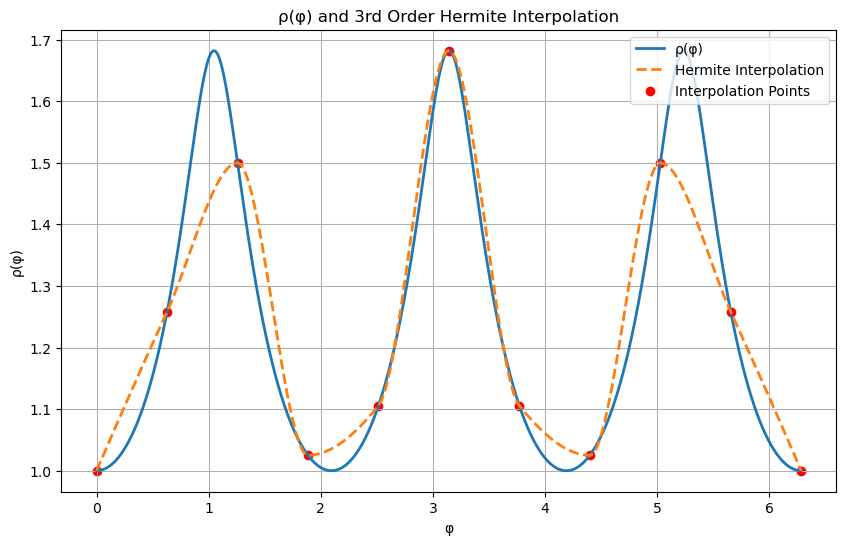

In [75]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

# Create subranges
N = 10  # Desired number of subranges
phi_values = np.linspace(0, 2*np.pi, N+1)

# Create points for Hermite interpolation
interp_points = list(zip(phi_values, rho(phi_values)))

# Create 3rd degree Hermite polynomial
hermite_interpolator = PchipInterpolator(*zip(*interp_points), extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# 𝜌(𝜙) function
rho_values = rho(phi_high_res)

# Hermite interpolation
hermite_values = hermite_interpolator(phi_high_res)

# Plot the graphs
plt.figure(figsize=(10, 6))
plt.plot(phi_high_res, rho_values, label='ρ(φ)', linewidth=2)
plt.plot(phi_high_res, hermite_values, label='Hermite Interpolation', linestyle='dashed', linewidth=2)
plt.scatter(*zip(*interp_points), color='red', label='Interpolation Points')
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.title('ρ(φ) and 3rd Order Hermite Interpolation')
plt.legend()
plt.grid(True)
plt.show()


### Plotting the graph for N = 50

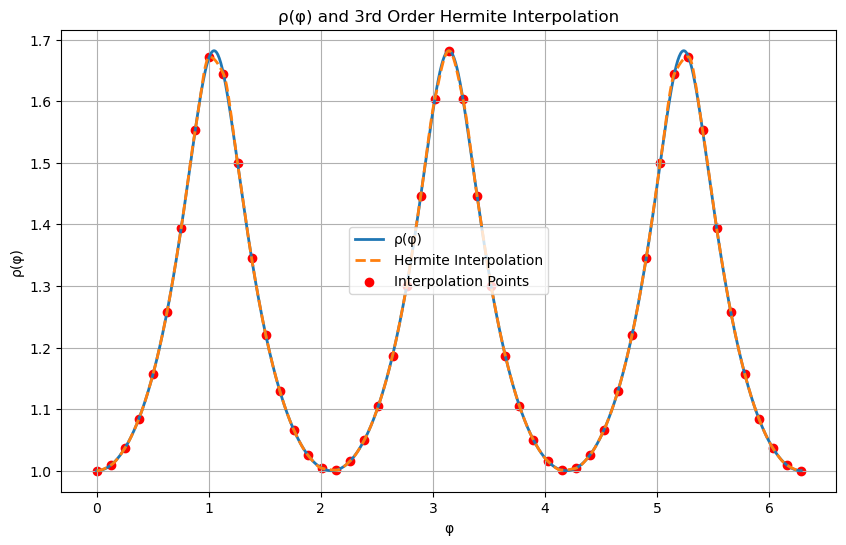

In [76]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

# Create subranges
N = 50  # İstenen alt aralık sayısı
phi_values = np.linspace(0, 2*np.pi, N+1)

# Create points for Hermite interpolation
interp_points = list(zip(phi_values, rho(phi_values)))

# Create 3rd degree Hermite polynomial
hermite_interpolator = PchipInterpolator(*zip(*interp_points), extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# 𝜌(𝜙) function
rho_values = rho(phi_high_res)

# Hermite interpolation
hermite_values = hermite_interpolator(phi_high_res)

# Plot the graphs
plt.figure(figsize=(10, 6))
plt.plot(phi_high_res, rho_values, label='ρ(φ)', linewidth=2)
plt.plot(phi_high_res, hermite_values, label='Hermite Interpolation', linestyle='dashed', linewidth=2)
plt.scatter(*zip(*interp_points), color='red', label='Interpolation Points')
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.title('ρ(φ) and 3rd Order Hermite Interpolation')
plt.legend()
plt.grid(True)
plt.show()


### Plotting the graph for N = 100


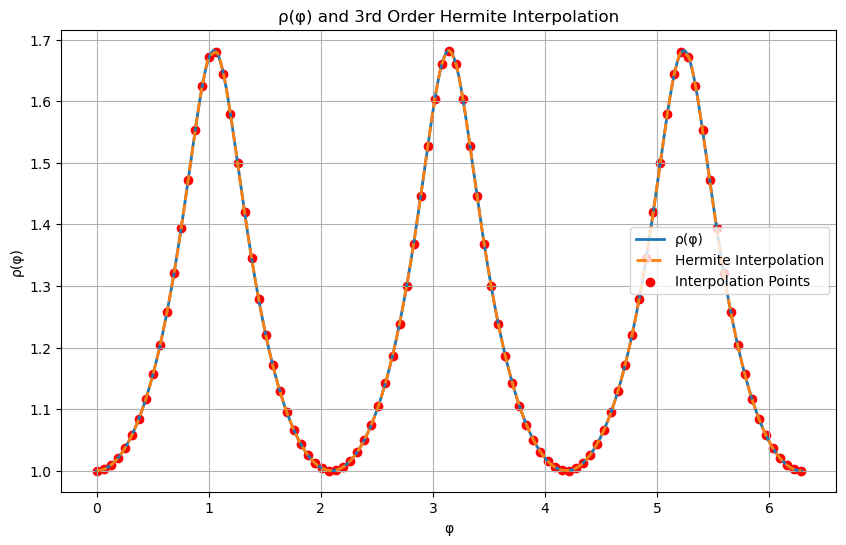

In [77]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

# Create subranges
N = 100  # Desired number of subranges
phi_values = np.linspace(0, 2*np.pi, N+1)

# Create points for Hermite interpolation
interp_points = list(zip(phi_values, rho(phi_values)))

# Create 3rd degree Hermite polynomial
hermite_interpolator = PchipInterpolator(*zip(*interp_points), extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# 𝜌(𝜙) function
rho_values = rho(phi_high_res)

# Hermite interpolation
hermite_values = hermite_interpolator(phi_high_res)

# Plot the graphs
plt.figure(figsize=(10, 6))
plt.plot(phi_high_res, rho_values, label='ρ(φ)', linewidth=2)
plt.plot(phi_high_res, hermite_values, label='Hermite Interpolation', linestyle='dashed', linewidth=2)
plt.scatter(*zip(*interp_points), color='red', label='Interpolation Points')
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.title('ρ(φ) and 3rd Order Hermite Interpolation')
plt.legend()
plt.grid(True)
plt.show()


The increase of the accuracy that between the results of Hermite Interpolation and 𝜌(𝜙) function can be observed when N is increasing. Based on this, it can be said that the result accuracy is directly proportional to the number of the subranges.

The value of the relative error is inversely proportional to the number of the subranges. For large but few subranges, the relative error will be larger than for small but more numerous subranges.

### Problem 1.d

### Plotting the graph for N = 10


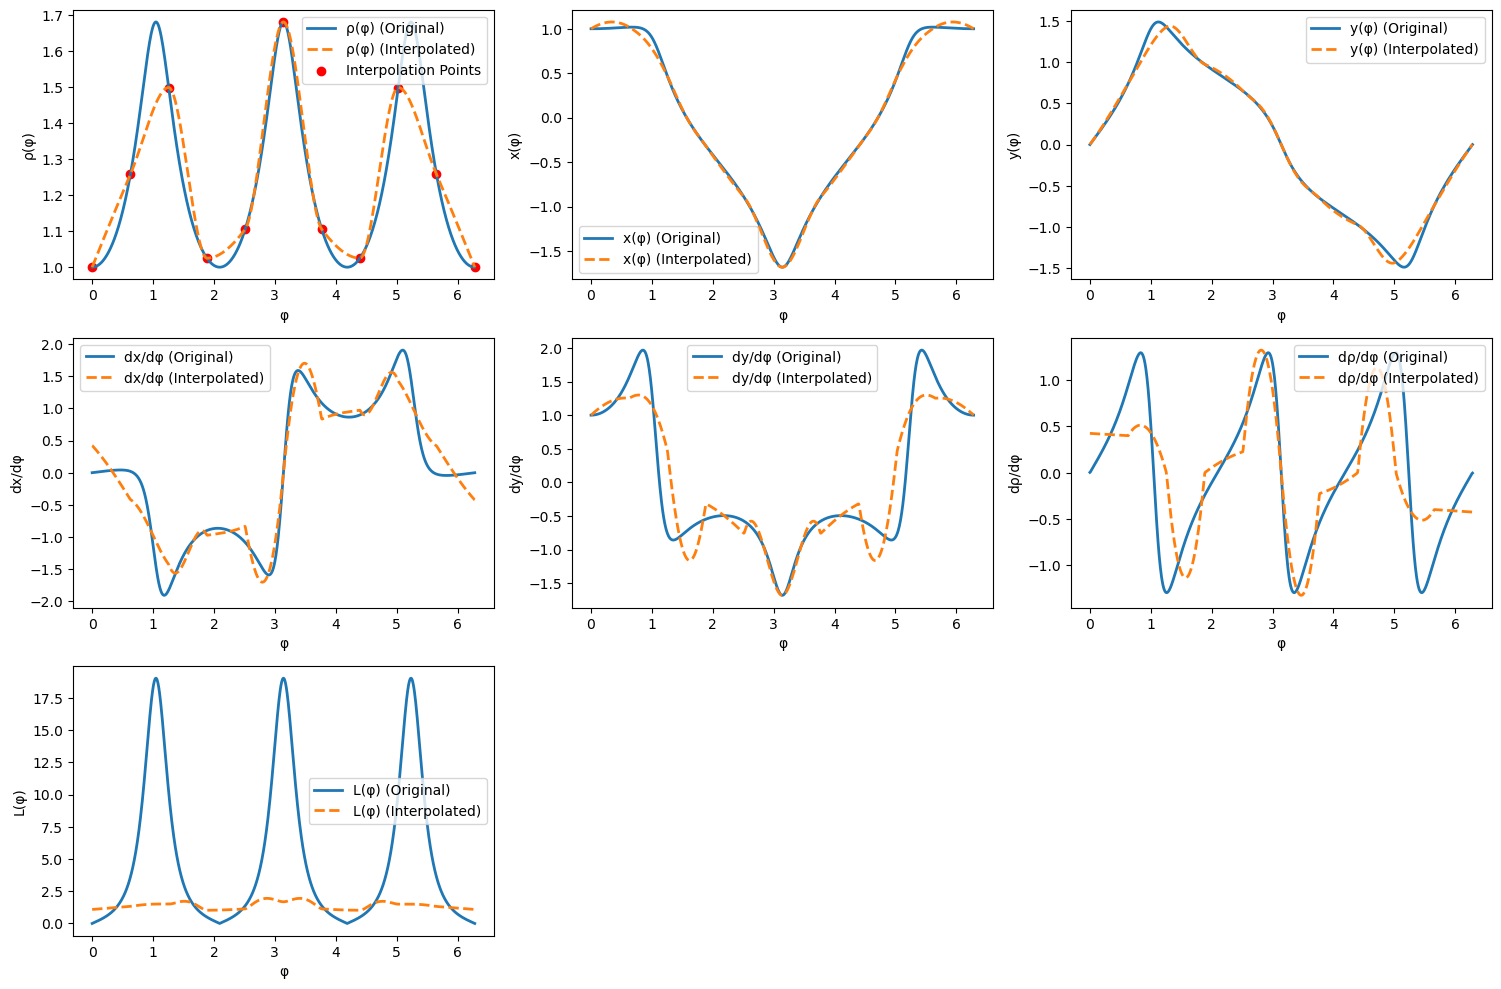

In [78]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

# 𝑥(𝜙) function
def x(phi):
    return rho(phi) * np.cos(phi)

# 𝑦(𝜙) function
def y(phi):
    return rho(phi) * np.sin(phi)

# 𝑙(𝜙) function
def L(phi):
    dx_dphi = -2 * np.sin(3*phi/4) * (np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-5/4) * np.cos(3*phi/4)
    dy_dphi = 2 * np.cos(3*phi/4) * (np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-5/4) * np.sin(3*phi/4)
    return np.sqrt(dx_dphi**2 + dy_dphi**2)

# Forward differences formula
def forward_difference(func_values, h):
    return np.gradient(func_values, h)

# Create subranges
N = 10  # Desired number of subranges
phi_values = np.linspace(0, 2*np.pi, N+1)

# Generate points for Hermite interpolation
interp_points = list(zip(phi_values, rho(phi_values)))

# Create 3rd degree Hermite polynomial
hermite_interpolator = PchipInterpolator(*zip(*interp_points), extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# 𝜌(𝜙) function
rho_values = rho(phi_high_res)

# Hermite interpolation
hermite_values = hermite_interpolator(phi_high_res)

# Calculate functions 𝑥(𝜙) and 𝑦(𝜙) using interpolation
x_interpolated = hermite_interpolator(phi_high_res) * np.cos(phi_high_res)
y_interpolated = hermite_interpolator(phi_high_res) * np.sin(phi_high_res)

# Calculate the functions 𝑑𝑥(𝜙)/𝑑𝜙 and 𝑑𝑦(𝜙)/𝑑𝜙 using interpolation
dx_dphi_interpolated = forward_difference(x_interpolated, phi_high_res[1] - phi_high_res[0])
dy_dphi_interpolated = forward_difference(y_interpolated, phi_high_res[1] - phi_high_res[0])

# Calculate the functions 𝑑𝜌(𝜙)/𝑑𝜙 and 𝐿(𝜙) using interpolation
drho_dphi_interpolated = forward_difference(hermite_interpolator(phi_high_res), phi_high_res[1] - phi_high_res[0])
L_values_interpolated = np.sqrt(dx_dphi_interpolated**2+ dy_dphi_interpolated**2)

# Plot the graphs
plt.figure(figsize=(15, 10))

# 𝜌(𝜙) function
plt.subplot(3, 3, 1)
plt.plot(phi_high_res, rho_values, label='ρ(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, hermite_values, label='ρ(φ) (Interpolated)', linestyle='dashed', linewidth=2)
plt.scatter(*zip(*interp_points), color='red', label='Interpolation Points')
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.legend()

# 𝑥(𝜙) function
plt.subplot(3, 3, 2)
plt.plot(phi_high_res, x(phi_high_res), label='x(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, x_interpolated, label='x(φ) (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('x(φ)')
plt.legend()

# 𝑦(𝜙) function
plt.subplot(3, 3, 3)
plt.plot(phi_high_res, y(phi_high_res), label='y(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, y_interpolated, label='y(φ) (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('y(φ)')
plt.legend()

# 𝑑𝑥(𝜙)/𝑑𝜙 function
plt.subplot(3, 3, 4)
plt.plot(phi_high_res, forward_difference(x(phi_high_res), phi_high_res[1] - phi_high_res[0]), label='dx/dφ (Original)', linewidth=2)
plt.plot(phi_high_res, dx_dphi_interpolated, label='dx/dφ (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dx/dφ')
plt.legend()

# 𝑑𝑦(𝜙)/𝑑𝜙 function
plt.subplot(3, 3, 5)
plt.plot(phi_high_res, forward_difference(y(phi_high_res), phi_high_res[1] - phi_high_res[0]), label='dy/dφ (Original)', linewidth=2)
plt.plot(phi_high_res, dy_dphi_interpolated, label='dy/dφ (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dy/dφ')
plt.legend()

# 𝑑𝜌(𝜙)/𝑑𝜙 function
plt.subplot(3, 3, 6)
plt.plot(phi_high_res, forward_difference(rho(phi_high_res), phi_high_res[1] - phi_high_res[0]), label='dρ/dφ (Original)', linewidth=2)
plt.plot(phi_high_res, drho_dphi_interpolated, label='dρ/dφ (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dρ/dφ')
plt.legend()

# 𝐿(𝜙) function
plt.subplot(3, 3, 7)
plt.plot(phi_high_res, L(phi_high_res), label='L(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, L_values_interpolated, label='L(φ) (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('L(φ)')
plt.legend()

# Show the graphs
plt.tight_layout()
plt.show()


### Plotting the graph for N = 100


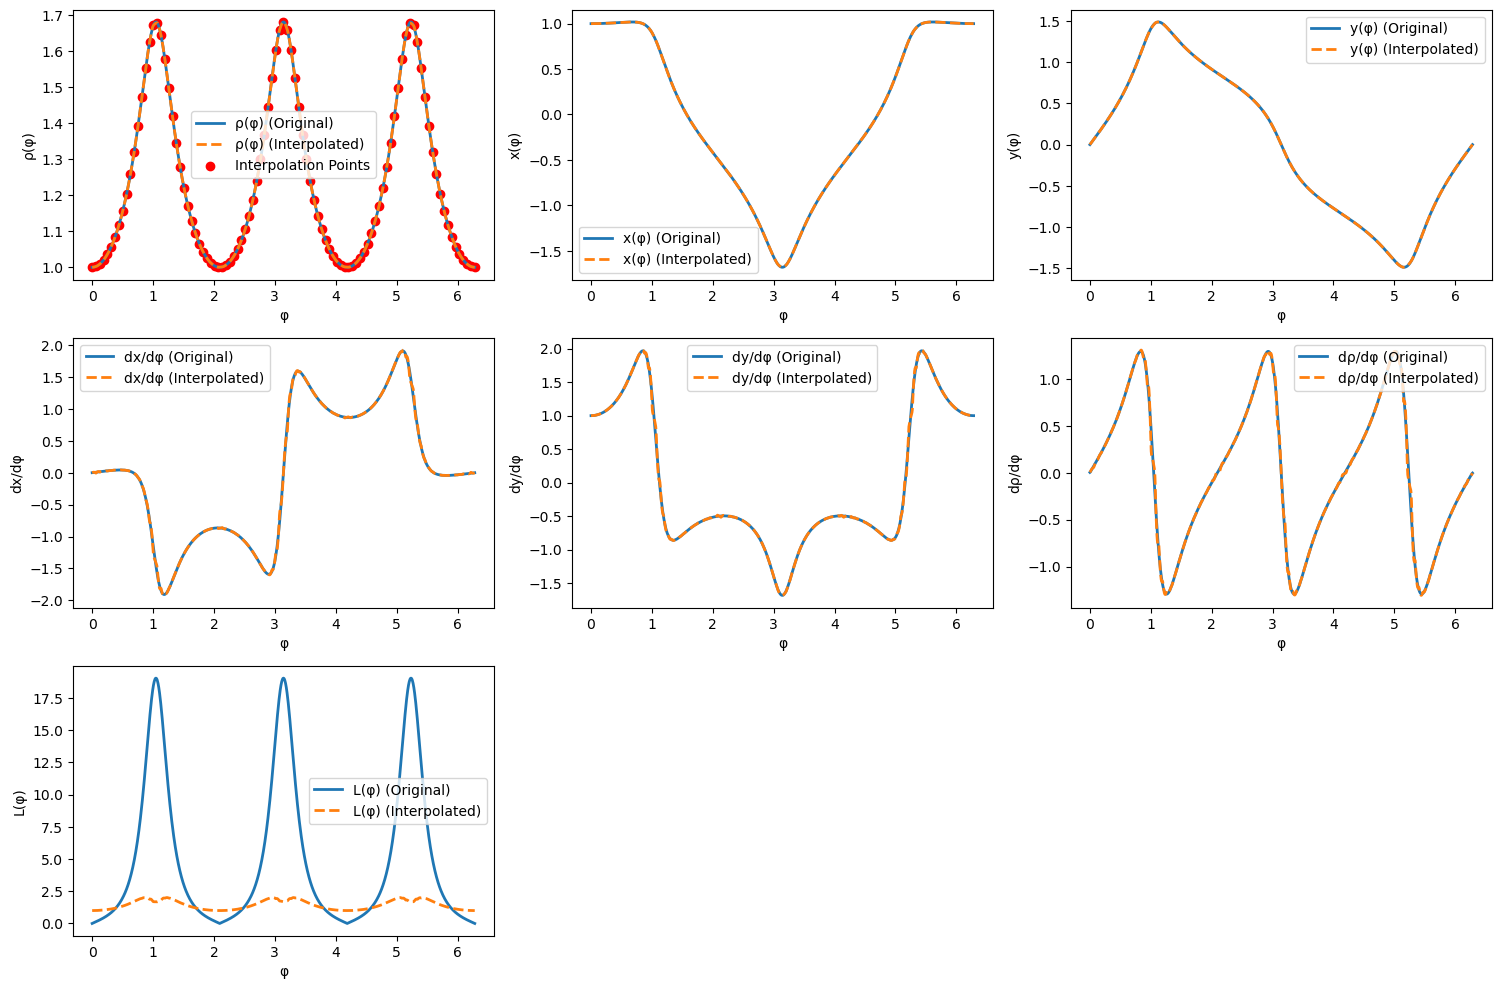

In [79]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

# 𝑥(𝜙) function
def x(phi):
    return rho(phi) * np.cos(phi)

# 𝑦(𝜙) function
def y(phi):
    return rho(phi) * np.sin(phi)

# 𝑙(𝜙) function
def L(phi):
    dx_dphi = -2 * np.sin(3*phi/4) * (np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-5/4) * np.cos(3*phi/4)
    dy_dphi = 2 * np.cos(3*phi/4) * (np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-5/4) * np.sin(3*phi/4)
    return np.sqrt(dx_dphi**2 + dy_dphi**2)

# Forward differences formula
def forward_difference(func_values, h):
    return np.gradient(func_values, h)

# Create subranges
N = 100  # Desired number of subranges
phi_values = np.linspace(0, 2*np.pi, N+1)

# Generate points for Hermite interpolation
interp_points = list(zip(phi_values, rho(phi_values)))

# Create 3rd degree Hermite polynomial
hermite_interpolator = PchipInterpolator(*zip(*interp_points), extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# 𝜌(𝜙) function
rho_values = rho(phi_high_res)

# Hermite interpolation
hermite_values = hermite_interpolator(phi_high_res)

# Calculate functions 𝑥(𝜙) and 𝑦(𝜙) using interpolation
x_interpolated = hermite_interpolator(phi_high_res) * np.cos(phi_high_res)
y_interpolated = hermite_interpolator(phi_high_res) * np.sin(phi_high_res)

# Calculate the functions 𝑑𝑥(𝜙)/𝑑𝜙 and 𝑑𝑦(𝜙)/𝑑𝜙 using interpolation
dx_dphi_interpolated = forward_difference(x_interpolated, phi_high_res[1] - phi_high_res[0])
dy_dphi_interpolated = forward_difference(y_interpolated, phi_high_res[1] - phi_high_res[0])

# Calculate the functions 𝑑𝜌(𝜙)/𝑑𝜙 and 𝐿(𝜙) using interpolation
drho_dphi_interpolated = forward_difference(hermite_interpolator(phi_high_res), phi_high_res[1] - phi_high_res[0])
L_values_interpolated = np.sqrt(dx_dphi_interpolated**2+ dy_dphi_interpolated**2)

# Plot the graphs
plt.figure(figsize=(15, 10))

# 𝜌(𝜙) function
plt.subplot(3, 3, 1)
plt.plot(phi_high_res, rho_values, label='ρ(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, hermite_values, label='ρ(φ) (Interpolated)', linestyle='dashed', linewidth=2)
plt.scatter(*zip(*interp_points), color='red', label='Interpolation Points')
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.legend()

# 𝑥(𝜙) function
plt.subplot(3, 3, 2)
plt.plot(phi_high_res, x(phi_high_res), label='x(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, x_interpolated, label='x(φ) (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('x(φ)')
plt.legend()

# 𝑦(𝜙) function
plt.subplot(3, 3, 3)
plt.plot(phi_high_res, y(phi_high_res), label='y(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, y_interpolated, label='y(φ) (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('y(φ)')
plt.legend()

# 𝑑𝑥(𝜙)/𝑑𝜙 function
plt.subplot(3, 3, 4)
plt.plot(phi_high_res, forward_difference(x(phi_high_res), phi_high_res[1] - phi_high_res[0]), label='dx/dφ (Original)', linewidth=2)
plt.plot(phi_high_res, dx_dphi_interpolated, label='dx/dφ (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dx/dφ')
plt.legend()

# 𝑑𝑦(𝜙)/𝑑𝜙 function
plt.subplot(3, 3, 5)
plt.plot(phi_high_res, forward_difference(y(phi_high_res), phi_high_res[1] - phi_high_res[0]), label='dy/dφ (Original)', linewidth=2)
plt.plot(phi_high_res, dy_dphi_interpolated, label='dy/dφ (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dy/dφ')
plt.legend()

# 𝑑𝜌(𝜙)/𝑑𝜙 function
plt.subplot(3, 3, 6)
plt.plot(phi_high_res, forward_difference(rho(phi_high_res), phi_high_res[1] - phi_high_res[0]), label='dρ/dφ (Original)', linewidth=2)
plt.plot(phi_high_res, drho_dphi_interpolated, label='dρ/dφ (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dρ/dφ')
plt.legend()

# 𝐿(𝜙) function
plt.subplot(3, 3, 7)
plt.plot(phi_high_res, L(phi_high_res), label='L(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, L_values_interpolated, label='L(φ) (Interpolated)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('L(φ)')
plt.legend()

# Show the graphs
plt.tight_layout()
plt.show()


As confirmed in option C, it can be said that overlap is directly proportional to number of the subranges (N). In addition, the fact that the relative error is inversely proportional to the number of the subranges is an inference that is confirmed again in these graphs.

### Problem 1.e

### Plotting the graph for N = 10

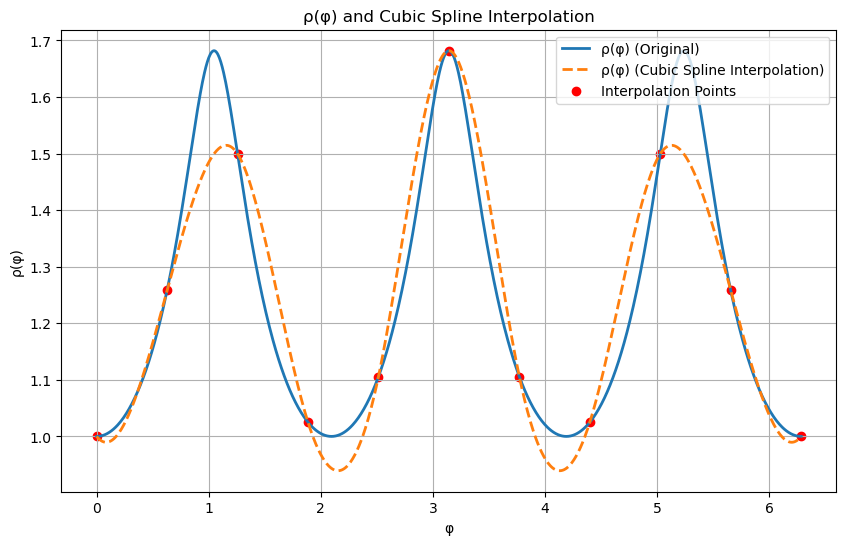

In [80]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

# Create subranges
N = 10  # Desired number of subranges
phi_values = np.linspace(0, 2*np.pi, N+1)

# Generate points for cubic spline interpolation
interp_points = list(zip(phi_values, rho(phi_values)))
spline_interpolator = CubicSpline(*zip(*interp_points), extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# 𝜌(𝜙) function
rho_values = rho(phi_high_res)

# Cubic spline interpolation
spline_values = spline_interpolator(phi_high_res)

# Plot the graphs
plt.figure(figsize=(10, 6))
plt.plot(phi_high_res, rho_values, label='ρ(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, spline_values, label='ρ(φ) (Cubic Spline Interpolation)', linestyle='dashed', linewidth=2)
plt.scatter(*zip(*interp_points), color='red', label='Interpolation Points')
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.title('ρ(φ) and Cubic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()


### Plotting the graph for N = 50

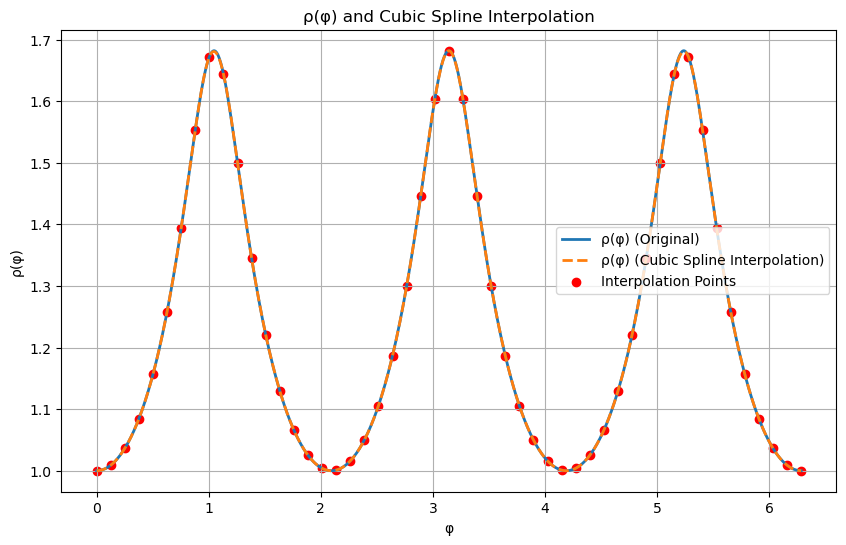

In [81]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

# Create subranges
N = 50  # Desired number of subranges
phi_values = np.linspace(0, 2*np.pi, N+1)

# Generate points for cubic spline interpolation
interp_points = list(zip(phi_values, rho(phi_values)))
spline_interpolator = CubicSpline(*zip(*interp_points), extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# 𝜌(𝜙) function
rho_values = rho(phi_high_res)

# Cubic spline interpolation
spline_values = spline_interpolator(phi_high_res)

# Plot the graphs
plt.figure(figsize=(10, 6))
plt.plot(phi_high_res, rho_values, label='ρ(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, spline_values, label='ρ(φ) (Cubic Spline Interpolation)', linestyle='dashed', linewidth=2)
plt.scatter(*zip(*interp_points), color='red', label='Interpolation Points')
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.title('ρ(φ) and Cubic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()


### Plotting the graph for N = 100

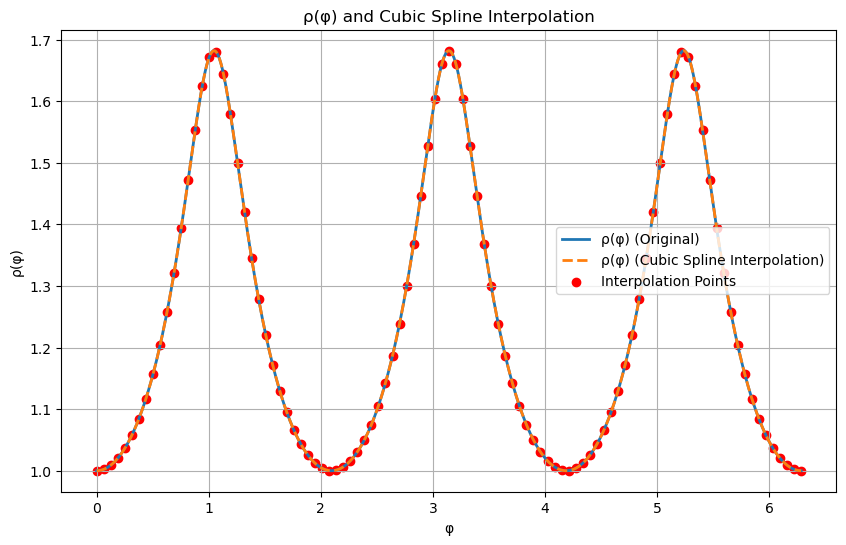

In [82]:
# 𝜌(𝜙) function
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

# Create subranges
N = 100  # Desired number of subranges
phi_values = np.linspace(0, 2*np.pi, N+1)

# Generate points for cubic spline interpolation
interp_points = list(zip(phi_values, rho(phi_values)))
spline_interpolator = CubicSpline(*zip(*interp_points), extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# 𝜌(𝜙) function
rho_values = rho(phi_high_res)

# Cubic spline interpolation
spline_values = spline_interpolator(phi_high_res)

# Plot the graphs
plt.figure(figsize=(10, 6))
plt.plot(phi_high_res, rho_values, label='ρ(φ) (Original)', linewidth=2)
plt.plot(phi_high_res, spline_values, label='ρ(φ) (Cubic Spline Interpolation)', linestyle='dashed', linewidth=2)
plt.scatter(*zip(*interp_points), color='red', label='Interpolation Points')
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.title('ρ(φ) and Cubic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()


In Cubic Spline Interpolation, a "subrange count-accuracy" and "subrange count-relative error" relationship similar to that in Hermit Interpolation was found. Apart from this, it has been observed that Cubic Spline Interpolation has smoother curves than Hermite Interpolation for different N values. There are multiple reasons for this, but it can be said that it is mainly due to the difference in derivative and polynomial degrees between the two interpolation methods.

### Problem 1.f

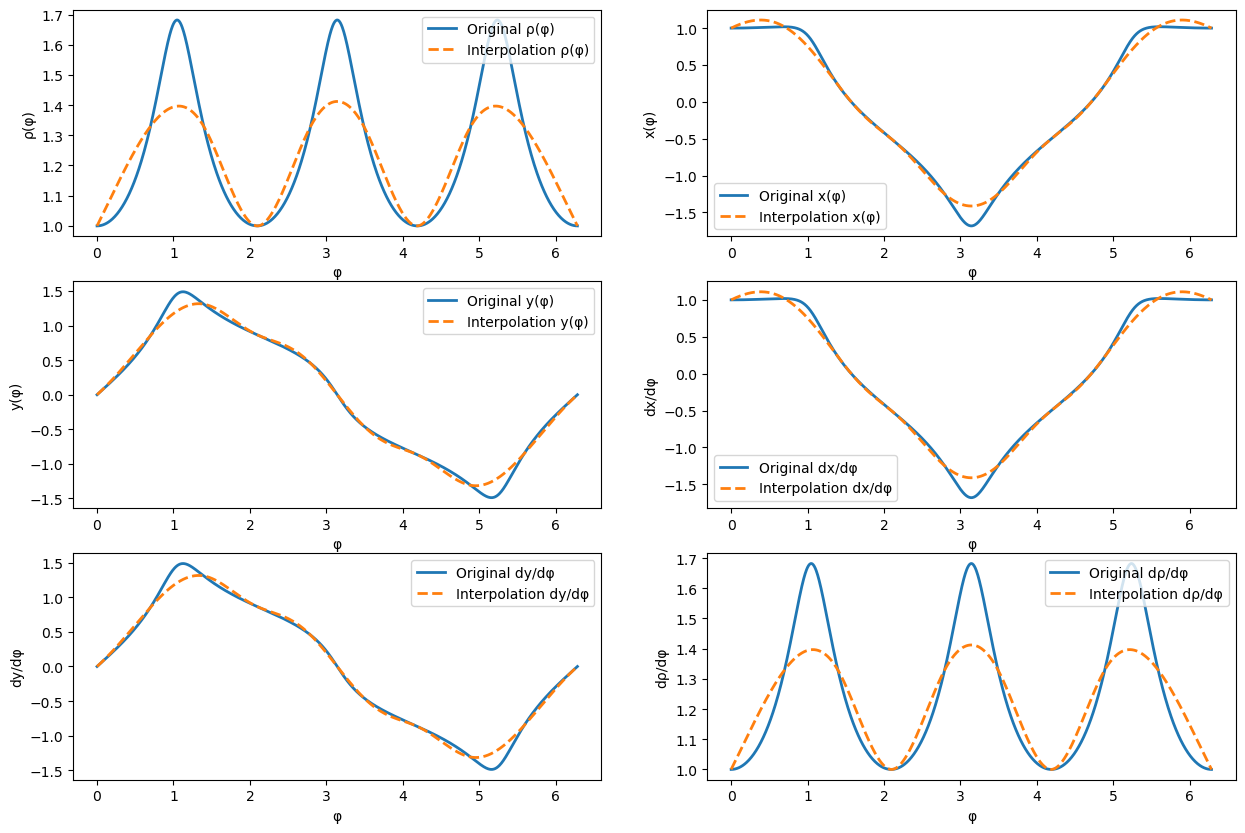

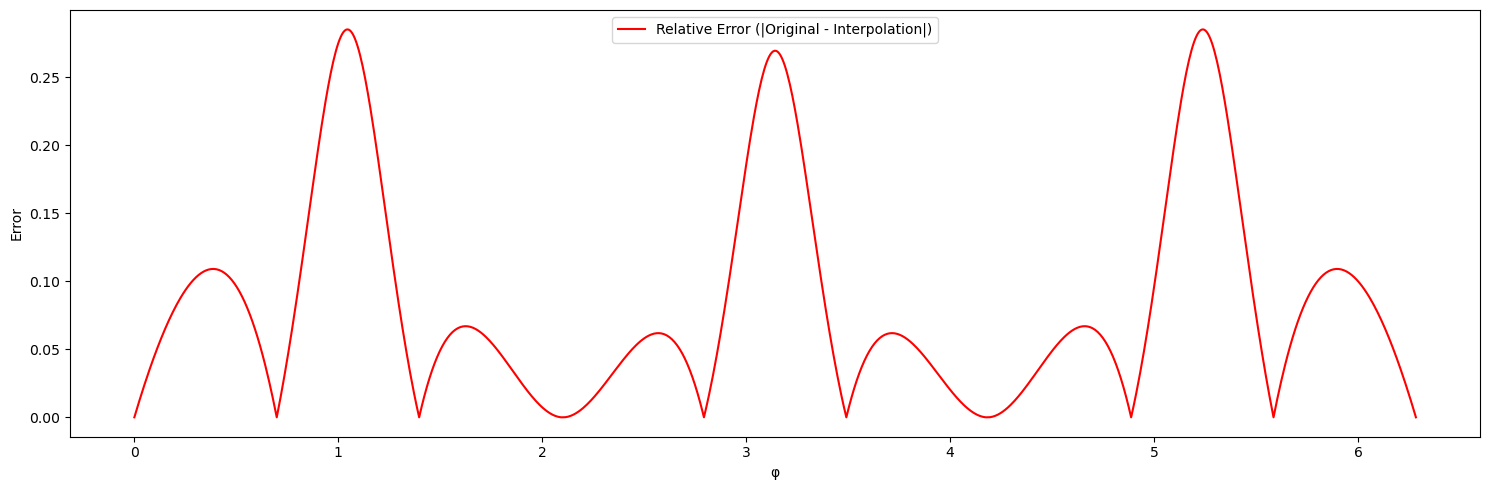

In [83]:
# Original functions
def rho(phi):
    return ((np.abs(np.cos(3*phi/4))**8 + np.abs(np.sin(3*phi/4))**8)**(-1/4))

def x(phi):
    return rho(phi) * np.cos(phi)

def y(phi):
    return rho(phi) * np.sin(phi)

# Data points
phi_values = np.linspace(0, 2*np.pi, 10)
rho_values = rho(phi_values)

# Cubic spline interpolation
spline_interpolator = CubicSpline(phi_values, rho_values, extrapolate=True)

# Generate high resolution 𝜙 values
phi_high_res = np.linspace(0, 2*np.pi, 1000)

# Original functions
rho_original = rho(phi_high_res)
x_original = x(phi_high_res)
y_original = y(phi_high_res)

# Functions calculated by cubic spline interpolation
rho_interpolated = spline_interpolator(phi_high_res)
x_interpolated = spline_interpolator(phi_high_res) * np.cos(phi_high_res)
y_interpolated = spline_interpolator(phi_high_res) * np.sin(phi_high_res)


# Compare the results in (b) and (e)
plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
plt.plot(phi_high_res, rho_original, label='Original ρ(φ)', linewidth=2)
plt.plot(phi_high_res, rho_interpolated, label='Interpolation ρ(φ)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('ρ(φ)')
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(phi_high_res, x_original, label='Original x(φ)', linewidth=2)
plt.plot(phi_high_res, x_interpolated, label='Interpolation x(φ)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('x(φ)')
plt.legend()

plt.subplot(3, 2, 3)
plt.plot(phi_high_res, y_original, label='Original y(φ)', linewidth=2)
plt.plot(phi_high_res, y_interpolated, label='Interpolation y(φ)', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('y(φ)')
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(phi_high_res, x_original, label='Original dx/dφ', linewidth=2)
plt.plot(phi_high_res, x_interpolated, label='Interpolation dx/dφ', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dx/dφ')
plt.legend()

plt.subplot(3, 2, 5)
plt.plot(phi_high_res, y_original, label='Original dy/dφ', linewidth=2)
plt.plot(phi_high_res, y_interpolated, label='Interpolation dy/dφ', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dy/dφ')
plt.legend()

plt.subplot(3, 2, 6)
plt.plot(phi_high_res, rho_original, label='Original dρ/dφ', linewidth=2)
plt.plot(phi_high_res, rho_interpolated, label='Interpolation dρ/dφ', linestyle='dashed', linewidth=2)
plt.xlabel('φ')
plt.ylabel('dρ/dφ')
plt.legend()

# Graph of the relative error
plt.figure(figsize=(15, 5))

plt.plot(phi_high_res, np.abs(rho_original - rho_interpolated), label='Relative Error (|Original - Interpolation|)', color='red')
plt.xlabel('φ')
plt.ylabel('Error')
plt.legend()

# Show the graphs
plt.tight_layout()
plt.show()


### Problem 1.g

In [84]:
pass

### Problem 1.h 

I enhanced my ability to perform simulations using the Python programming language, utilizing the NumPy and Matplotlib libraries. By plotting the 𝜌(𝜙) function in polar coordinates and subsequently in the x-y plane, I learned how to effectively visualize mathematical concepts. This experience also enabled me to gain proficiency in computing the tangent vector 𝒍(𝝓) and 𝑔(𝜙) function using forward difference, backward difference, and other numerical computation methods, contributing to a better understanding of real-world physical processes. Additionally, the process of interpolating with a 3rd-degree Hermite polynomial developed my skill in representing data sets with smoother functions. 

# REFERENCES

[1] ChatGPT, “https://chat.openai.com”. (The quoted solutions and code are included in the report.)
    
[2] Numerical Analysis, 9th ed.

[3] Stack Overflow, https://stackoverflow.com/questions/31543775/how-to-perform-cubic-spline-interpolation-in-python, Cubic Spline Interpolation

[4] GeeksForGeeks, https://www.geeksforgeeks.org/cubic-spline-interpolation/, Cubic Spline Interpolation

[5] GitHub, https://github.com/topics/hermite-interpolation, Cubic Spline Interpolation and Hermite Interpolation

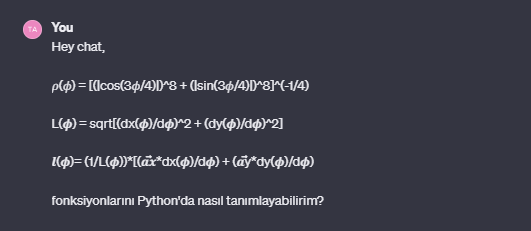

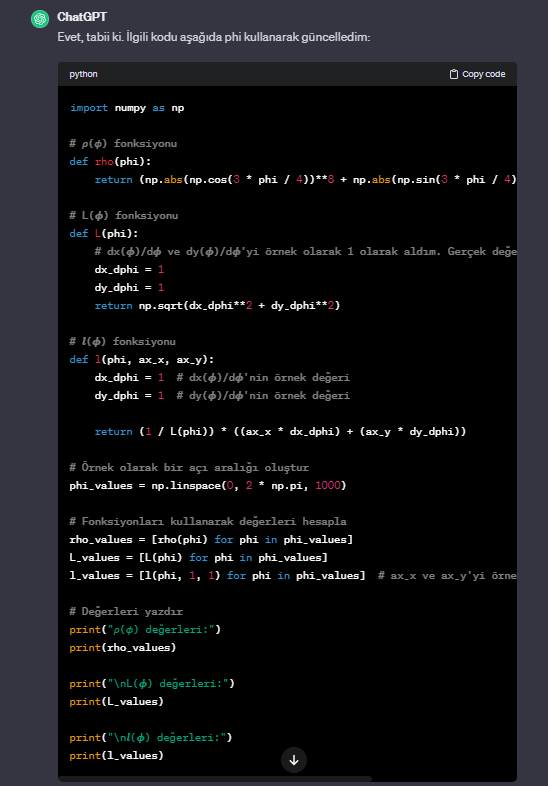

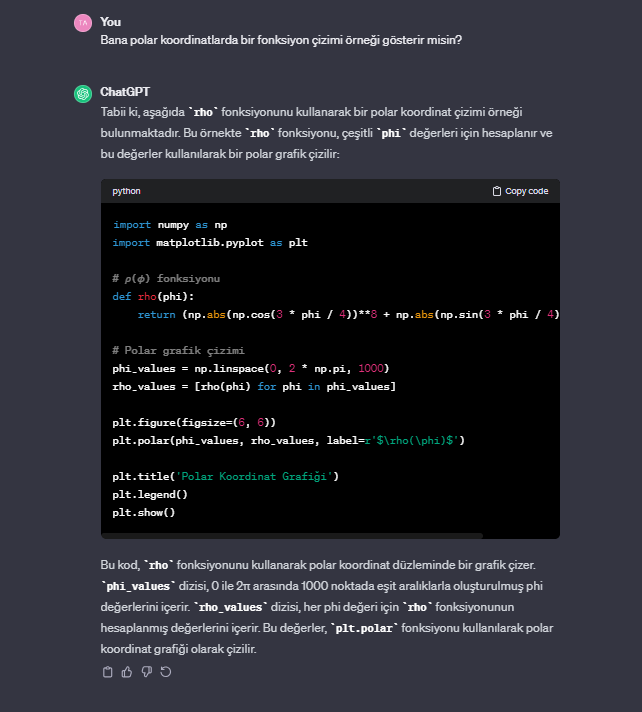

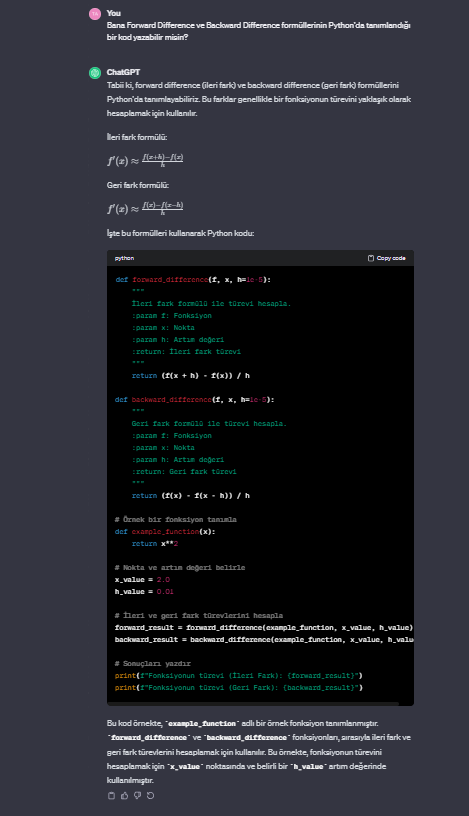

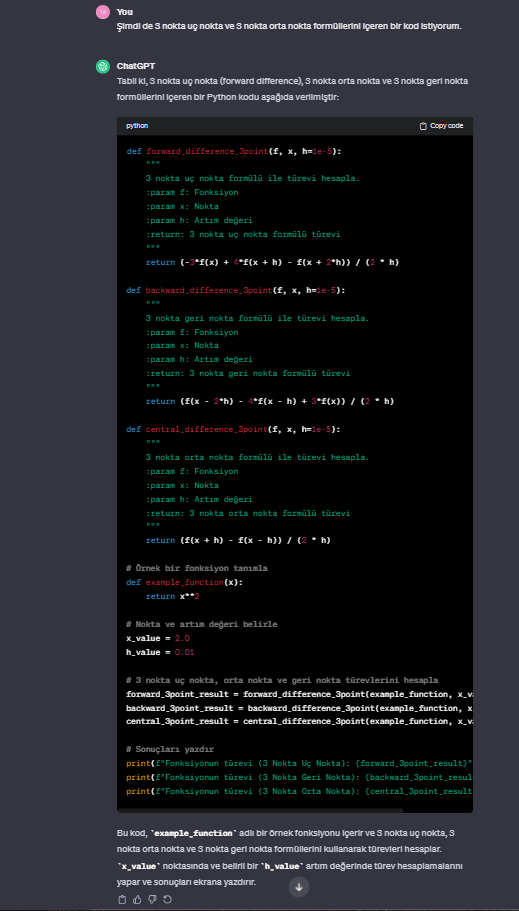

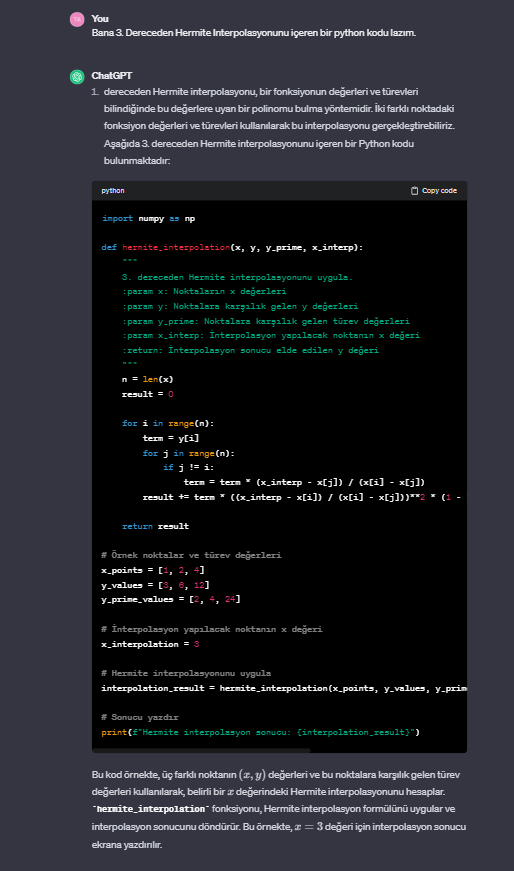

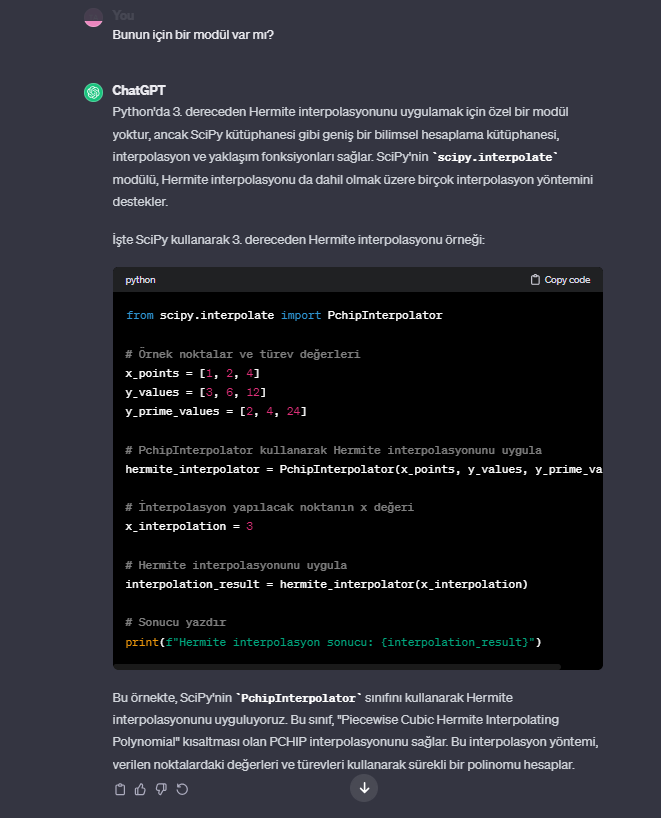

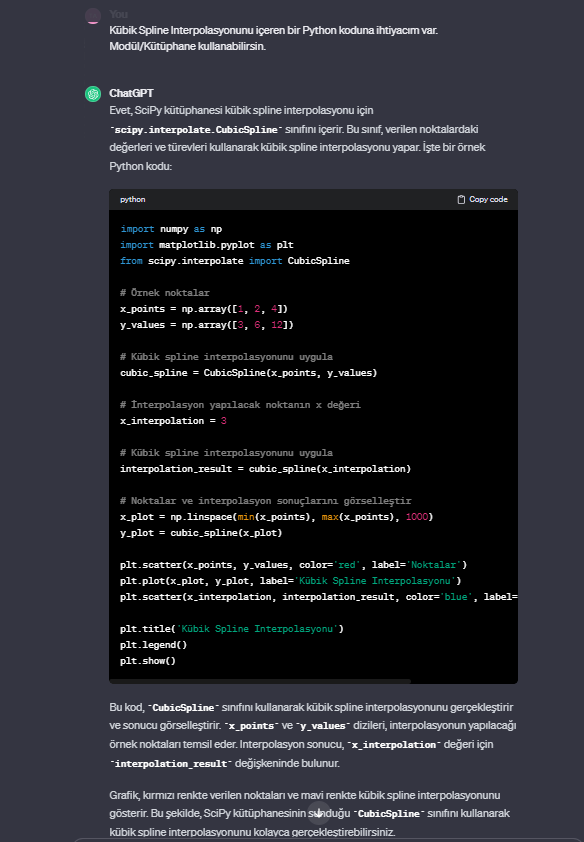